In [23]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [2]:
# step up to project root from the notebook folder to find the compiled binary
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
build_dir = os.path.join(project_root, "build")
sys.path.append(build_dir)

# handle windows mingw dll runtime dependencies safely
for path_dir in os.environ.get("PATH", "").split(os.pathsep):
    if os.path.exists(os.path.join(path_dir, "g++.exe")) or os.path.exists(os.path.join(path_dir, "gcc.exe")):
        os.add_dll_directory(path_dir)
        break

In [3]:
import autograd_cpp
print("autograd-cpp library loaded successfully")

autograd-cpp library loaded successfully


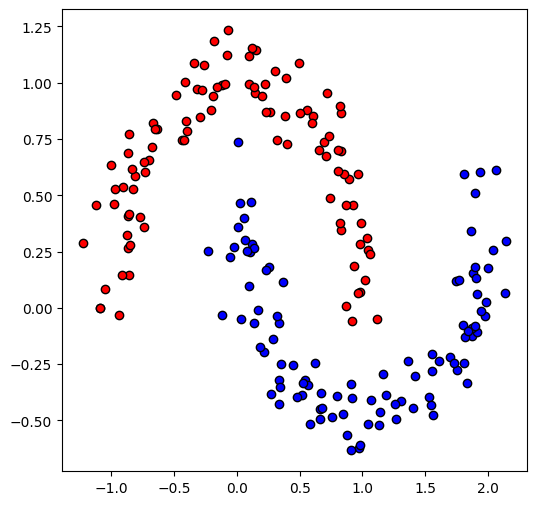

In [24]:
# generate a noisy concentric circles dataset that linear models cannot solve
X, y = make_moons(n_samples=200, noise=0.10, random_state=42)

# plot the raw dataset
plt.figure(figsize=(6, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', label='class 0', edgecolors='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='class 1', edgecolors='k')
plt.grid(False)
plt.show()

In [26]:
# 2 input features (x, y coordinates) -> hidden layers -> 2 output logits (class scores)
model = autograd_cpp.MLP(2, [16, 16, 2], "tanh", 1337)

# cross entropy loss engine for multiclass classification
criterion = autograd_cpp.CrossEntropyLoss()

# advanced sgd with momentum and weight decay parameters
optimizer = autograd_cpp.optim.SGD(model.parameters(), lr=0.02, momentum=0.9, weight_decay=1e-4)

print(f"initialized model with {len(model.parameters())} parameters")

initialized model with 354 parameters


In [27]:
# train sample-by-sample since our engine graph handles scalars
epochs = 15
loss_hist = []

for epoch in range(epochs):
    total_loss = 0.0
    
    # shuffle index sequence every epoch for stochastic updates
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    for idx in indices:
        # pack raw values into autograd-cpp tracking nodes
        x_nodes = [autograd_cpp.make_val(float(X[idx][0])), autograd_cpp.make_val(float(X[idx][1]))]
        target_class = int(y[idx])
        
        # forward pass
        logits = model.forward(x_nodes)
        
        # calculate loss
        loss = criterion(logits, target_class)
        total_loss += loss.data
        
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # update
        optimizer.step()
        
    average_loss = total_loss / len(X)
    loss_hist.append(average_loss)
    print(f"epoch {epoch+1:02d}/{epochs:02d} | average loss: {average_loss:.4f}")

epoch 01/15 | average loss: 0.6182
epoch 02/15 | average loss: 0.3848
epoch 03/15 | average loss: 0.2342
epoch 04/15 | average loss: 0.1822
epoch 05/15 | average loss: 0.1524
epoch 06/15 | average loss: 0.2587
epoch 07/15 | average loss: 0.1929
epoch 08/15 | average loss: 0.1287
epoch 09/15 | average loss: 0.1659
epoch 10/15 | average loss: 0.0535
epoch 11/15 | average loss: 0.0906
epoch 12/15 | average loss: 0.0720
epoch 13/15 | average loss: 0.0537
epoch 14/15 | average loss: 0.0210
epoch 15/15 | average loss: 0.0354


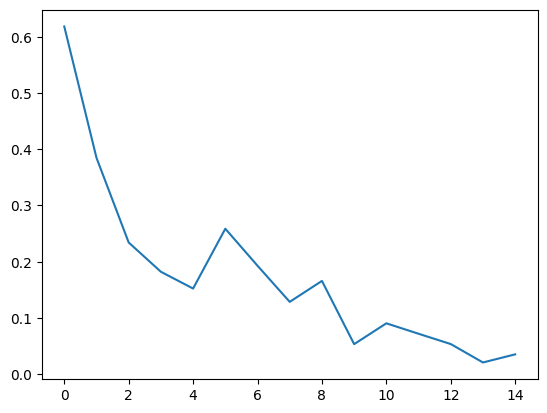

In [28]:
plt.plot(loss_hist)

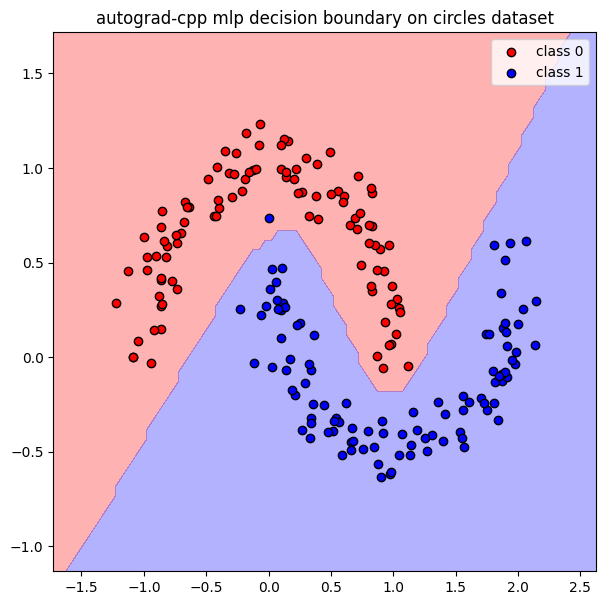

In [29]:
# generate a dense grid over the feature area to visualize decisions
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

grid_points = np.c_[xx.ravel(), yy.ravel()]
predictions = []

# pass grid coordinate matrices through the network
for pt in grid_points:
    x_nodes = [autograd_cpp.make_val(float(pt[0])), autograd_cpp.make_val(float(pt[1]))]
    logits = model.forward(x_nodes)
    
    # pick the index of the largest score score (argmax)
    pred_class = 0 if logits[0].data > logits[1].data else 1
    predictions.append(pred_class)

# reshape results back to match the mesh layout
Z = np.array(predictions).reshape(xx.shape)

# render decision contours along with original scatter elements
plt.figure(figsize=(7, 7))
plt.contourf(xx, yy, Z, alpha=0.3, levels=[-1, 0, 1], colors=['red', 'blue'])
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', label='class 0', edgecolors='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='class 1', edgecolors='k')
plt.title("autograd-cpp mlp decision boundary on circles dataset")
plt.legend()
plt.show()